# Protein Thinking: Cost-Constrained Student Meal Planning

## tl;dr

The balanced model finds a **€44.37** illustrative weekly basket with **160.1 g average protein per day** and **18 distinct foods**. Raising the protein floor from 130 g to 210 g adds **€19.76 per week** under the same catalogue and constraints. The convenience scenario limits active preparation to 35 minutes per day and costs €49.60.

## Context & Methods

**Decision question:** What is the lowest-cost seven-day grocery basket that satisfies a chosen average nutrition target while remaining varied and practical?

The analysis uses two mixed-integer stages. Stage 1 minimises basket cost subject to weekly nutrition, variety, food-frequency and preparation constraints. Stage 2 fixes that basket and allocates servings across seven days to reduce day-to-day variation.

### Key Assumptions

- Prices are illustrative Dutch retail assumptions, not a live supermarket feed.
- Nutrition values are representative product-label values.
- Nutrition constraints apply to the weekly average; the daily schedule is illustrative.
- The outputs describe this model setup; they are not dietary or medical advice.

## Data

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/protein-thinking-matplotlib')
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
PROCESSED = ROOT / 'data' / 'processed'
summary = pd.read_csv(PROCESSED / 'scenario_summary.csv')
frontier = pd.read_csv(PROCESSED / 'protein_frontier.csv')
daily = pd.read_csv(PROCESSED / 'daily_summary.csv')
grocery = pd.read_csv(PROCESSED / 'grocery_list.csv')
print(summary[['scenario_label', 'weekly_cost_eur', 'average_protein_g', 'average_prep_minutes', 'unique_foods']].to_string(index=False))

scenario_label  weekly_cost_eur  average_protein_g  average_prep_minutes  unique_foods
      Balanced            44.37              160.1                  55.0            18
    Budget cut            41.06              150.0                  58.6            16
  High protein            51.76              190.0                  59.6            19
   Convenience            49.60              160.4                  35.0            21


### Validate the analytical outputs

In [2]:
assert summary['solver_mip_gap'].fillna(0).le(0.001).all()
assert daily.groupby('scenario')['day'].nunique().eq(7).all()
assert frontier['protein_floor_g'].is_monotonic_increasing
assert frontier['weekly_cost_eur'].is_monotonic_increasing
print('Core reconciliation and optimisation checks passed.')

Core reconciliation and optimisation checks passed.


## Results

### Scenario comparison

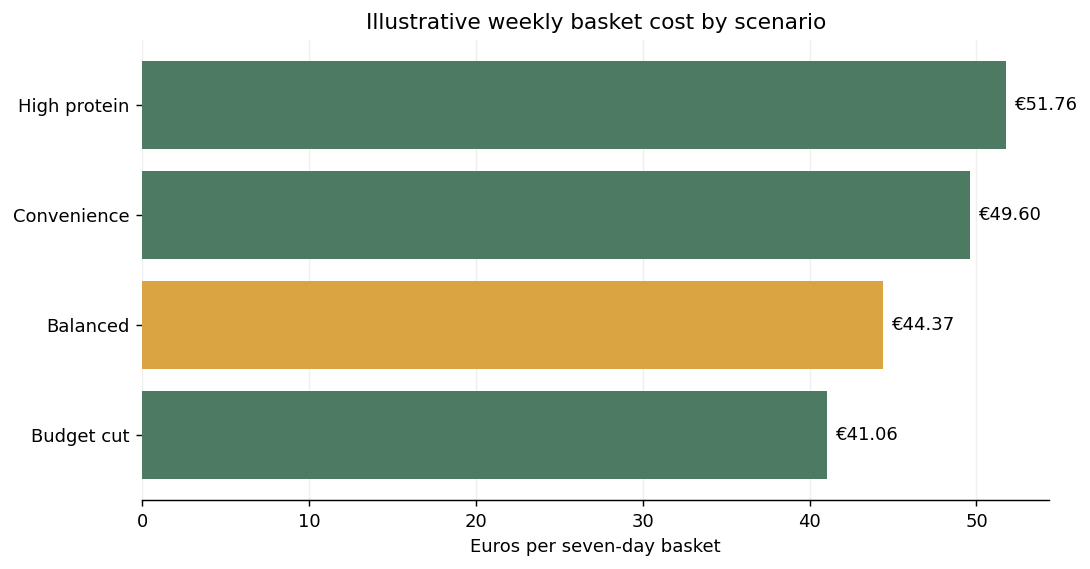

In [3]:
plot_data = summary.sort_values('weekly_cost_eur')
colors = ['#d9a441' if label == 'Balanced' else '#4d7a62' for label in plot_data['scenario_label']]
fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(plot_data['scenario_label'], plot_data['weekly_cost_eur'], color=colors)
ax.bar_label(bars, labels=[f'€{value:.2f}' for value in plot_data['weekly_cost_eur']], padding=5)
ax.set(title='Illustrative weekly basket cost by scenario', xlabel='Euros per seven-day basket')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=.2)
ax.set_axisbelow(True)
plt.show()

### Protein-cost sensitivity

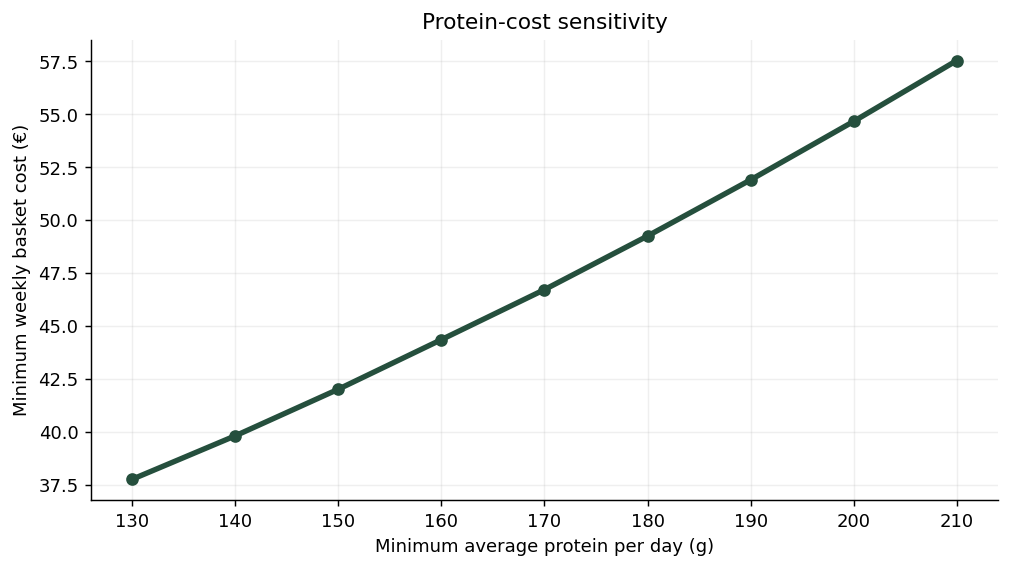

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(frontier['protein_floor_g'], frontier['weekly_cost_eur'], color='#254f3d', linewidth=3, marker='o')
ax.set(title='Protein-cost sensitivity', xlabel='Minimum average protein per day (g)', ylabel='Minimum weekly basket cost (€)')
ax.grid(alpha=.2)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

### Balanced grocery basket

In [5]:
balanced_grocery = (grocery[grocery['scenario'] == 'balanced']
    .sort_values('weekly_cost_eur', ascending=False)
    [['food_name', 'category', 'servings', 'weekly_cost_eur']])
print(balanced_grocery.head(12).to_string(index=False))

        food_name      category  servings  weekly_cost_eur
   Chicken thighs          meat         3             6.00
     Whey protein    supplement         7             5.25
Semi-skimmed milk         dairy         9             3.42
             Skyr         dairy         2             3.20
        Firm tofu plant protein         2             3.00
  Lean beef mince          meat         1             2.60
   Chicken breast          meat         1             2.50
     Kidney beans        legume         3             2.40
             Eggs       protein         4             2.40
 Wholegrain bread         grain         8             2.24
           Banana         fruit         7             2.10
          Carrots     vegetable         7             2.10


## Takeaways

1. **Protein is a measurable cost driver.** Moving from 130 g to 210 g adds €19.76 per illustrative week.
2. **Convenience has a premium.** The 35-minute preparation cap produces a €49.60 basket, €5.23 above the balanced case.
3. **The high-protein constraint changes the purchasing decision.** The 190 g scenario costs €51.76, compared with €44.37 for the balanced scenario.

These are optimisation outputs under a controlled illustrative catalogue. A real decision would require current product prices, verified labels and personalised requirements.